In [23]:
from dotenv import load_dotenv
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
load_dotenv()

True

In [24]:
# from langchain_google_genai import ChatGoogleGenerativeAI
# llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

from langchain_groq import ChatGroq
llm = ChatGroq(model="openai/gpt-oss-120b")

In [25]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

In [26]:
# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


In [27]:
def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}

In [28]:
def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}

In [29]:
def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}

In [30]:
# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

In [31]:
# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()


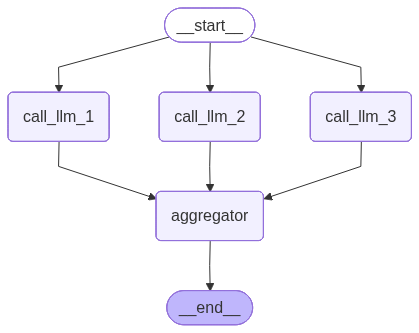

In [32]:
# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

In [33]:
# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

Here's a story, joke, and poem about cats!

STORY:
**The Midnight Council of Whisker‑Hill**

When the sun slipped behind the rooftops of the sleepy town of Brindleford, the ordinary world seemed to exhale a sigh of relief. The streetlights flickered on, casting amber pools on cobblestones, and the last of the humans shuffled home, locking doors and turning off the lights. In the shadows, however, another sort of life stirred—one that had watched the town from high perches and hidden alleys for centuries.

At the heart of Brindleford, perched atop the cracked stone wall of the old clock tower, sat a circle of cats unlike any you’d find in a typical alley. They called themselves the **Midnight Council**, and each member bore a title earned through daring deeds, cleverness, or sheer feline charm.

---

### 1. Sir Pounce‑alot, the Brave

Sir Pounce‑alot was a sleek, silver‑tabby with a scar that traced a perfect “V” across his left ear—a souvenir from a battle with a rogue garden gnome. He